In [ ]:
!pip install -q transformers datasets evaluate seqeval accelerate corus razdel

# Библиотеки + сид + базовая модель

In [2]:
import os
import requests
import torch
import gc
import seqeval
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import Dataset, DatasetDict, load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForMaskedLM,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    DataCollatorForLanguageModeling,
    DataCollatorForWholeWordMask,
    pipeline,
    set_seed
)
import evaluate
from razdel import tokenize as razdel_tokenize, sentenize as razdel_sentenize

SIX SEVEN

In [3]:
set_seed(67)

Берем базированные rubert от Deep Pavlov

In [4]:
MODEL_CHECKPOINT = "DeepPavlov/rubert-base-cased"

results_summary = {}

# Скачивание данных + EDA + Preprocessing

Тут ничего интересного, просто качаем датасетик

In [5]:
def factrueval_dataset(split_name):
    url = f"https://huggingface.co/datasets/gusevski/factrueval2016/resolve/main/{split_name}_data.json"
    data = requests.get(url).json()
    if isinstance(data, dict) and "data" in data:
        data = data["data"]
    return Dataset.from_pandas(pd.DataFrame(data))

raw_datasets = DatasetDict({
    "train": factrueval_dataset("train"),
    "test": factrueval_dataset("test"),
    "dev": factrueval_dataset("dev")
})

Передали словари с метками

In [6]:
id2label = {}
for tags_int, tags_str in zip(raw_datasets['train']['ner_tags'], raw_datasets['train']['ner_tags_str']):
    for tag_id, tag_name in zip(tags_int, tags_str):
        if tag_id not in id2label:
            id2label[tag_id] = tag_name

id2label = dict(sorted(id2label.items()))
label2id = {v: k for k, v in id2label.items()}
label_names = [id2label.get(i, f"LABEL_{i}") for i in range(max(id2label.keys()) + 1)]

Посмотрим как у нас выглядит распределение длин последовательностей + как выглядит баланс классов

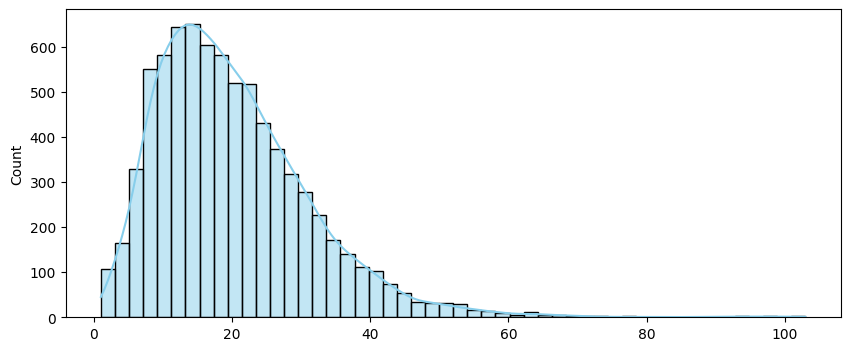

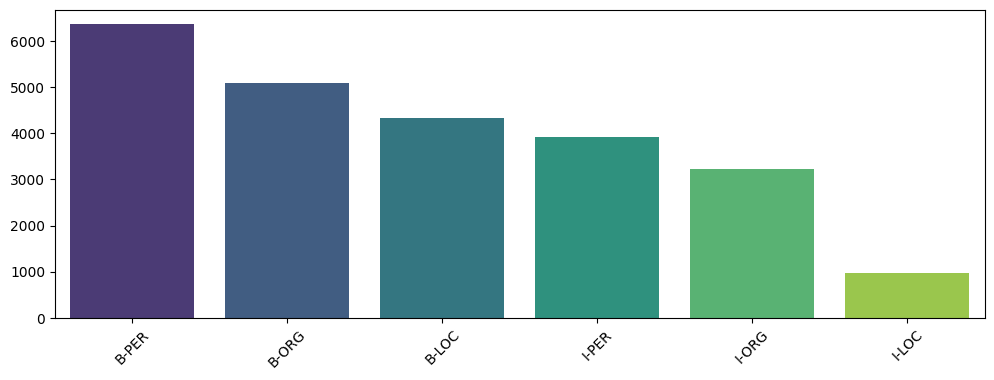

In [7]:
seq_lengths = [len(example['tokens']) for example in raw_datasets['train']]

plt.figure(figsize=(10, 4))
sns.histplot(seq_lengths, bins=50, kde=True, color='skyblue')
plt.show()

all_tags = []
for tags in raw_datasets['train']['ner_tags']:
    all_tags.extend(tags)

tag_counts = Counter(all_tags)
tag_counts_named = {label_names[k]: v for k, v in tag_counts.items()}
if 'O' in tag_counts_named:
    tag_counts_named.pop('O')

tag_counts_named = dict(sorted(tag_counts_named.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(12, 4))
sns.barplot(x=list(tag_counts_named.keys()), y=list(tag_counts_named.values()), hue=list(tag_counts_named.keys()), legend=False, palette="viridis")
plt.xticks(rotation=45)
plt.show()

max_length по идее можно взять 110, чтобы с запасом все покрыть

по поводу баланса, то даже не знаю. Особо сильного дисбаланса нет, то есть должны более менее ровно выделять все классы.

Сделаем выравнивание, чтобы при разбиение на токены мы не сломались из-за несоответствия кол-ва токенов и кол-ва меток, также будем давать метку только для первого токена, а остальные токены в слове игнорим (делаем -100 индекс им)



In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], truncation=True, is_split_into_words=True, max_length=110
    )
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = raw_datasets.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=raw_datasets["train"].column_names
)

Берем базовые метрики, также для каждой метки тоже будет считать отдельно F1 score

и используем либу seqeval, чтобы оценивать кач-во извлечения целыз сущностей

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_names[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_names[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)

    metrics_dict = {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

    for entity in ["PER", "LOC", "ORG"]:
        if entity in results:
            metrics_dict[f"f1_{entity}"] = results[entity]["f1"]

    return metrics_dict

# Обучаем модели

## Baseline

Напоминаю что за базовую модель у меня взята `DeepPavlov/rubert-base-cased`

In [10]:
def run_ner_experiment(checkpoint, output_dir, train_dataset, eval_dataset):
    model = AutoModelForTokenClassification.from_pretrained(
        checkpoint,
        id2label=id2label,
        label2id=label2id
    )

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=4,
        weight_decay=0.01,
        save_strategy="no",
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    zero_shot_metrics = trainer.evaluate()
    trainer.train()
    post_train_metrics = trainer.evaluate()

    return zero_shot_metrics, post_train_metrics

In [11]:
zero_shot_metrics, baseline_metrics = run_ner_experiment(
    checkpoint=MODEL_CHECKPOINT,
    output_dir="./ner-baseline",
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"]
)

print("-------------------- РЕЗУЛЬТАТЫ --------------------")
print(f"До {zero_shot_metrics['eval_f1']:.4f}")
print(f"После {baseline_metrics['eval_f1']:.4f}")

results_summary["Zero-Shot"] = zero_shot_metrics['eval_f1']
results_summary["Baseline"] = baseline_metrics['eval_f1']

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                          

Epoch,Training Loss,Validation Loss,Model Preparation Time,Precision,Recall,F1,Accuracy,F1 Per,F1 Loc,F1 Org
1,0.028332,0.020476,0.017600,0.967489,0.968727,0.968107,0.994060,0.993341,0.982850,0.924634
2,0.011766,0.018307,0.017600,0.969456,0.980980,0.975184,0.995195,0.994262,0.986037,0.943344
3,0.007271,0.017017,0.017600,0.981938,0.984272,0.983103,0.996462,0.995411,0.987082,0.964726
4,0.003489,0.015818,0.017600,0.981414,0.985004,0.983206,0.996595,0.994719,0.989055,0.964306


-------------------- РЕЗУЛЬТАТЫ --------------------
До 0.0380
После 0.9832


Результаты конечно бомбические, вот бы всегда такие метрики получать

## MLM + NER

В этом блоке мы возьем MLM мы дообучим на нашем корпусе и это должно дать более крутые результаты чем бейзлайн, так как в baseline мы полагаемся на базовые знания, которые были заложены при обучении оригинаьной модели. А тут мы даем MLM ознакомиться с нашим контекстом, чтобы лучше его понимать

In [12]:
def train_mlm_model(dataset, checkpoint, output_dir):
    model = AutoModelForMaskedLM.from_pretrained(checkpoint)
    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)

    args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=2e-5,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        save_strategy="no",
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset,
        data_collator=collator,
    )

    trainer.train()
    trainer.model.save_pretrained(output_dir)
    return output_dir

In [13]:
def run_ner_after_mlm(checkpoint, train_dataset, eval_dataset):
    model = AutoModelForTokenClassification.from_pretrained(
        checkpoint,
        id2label=id2label,
        label2id=label2id
    )

    args = TrainingArguments(
        output_dir="./ner-after-mlm",
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=4,
        weight_decay=0.01,
        save_strategy="no",
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    return trainer.evaluate()

In [ ]:
def prepare_mlm_dataset(examples):
    return tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=110,
        is_split_into_words=True
    )

mlm_datasets = raw_datasets.map(
    prepare_mlm_dataset,
    batched=True,
    remove_columns=raw_datasets["train"].column_names
)

In [15]:
mlm_weights_path = train_mlm_model(
    mlm_datasets["train"],
    MODEL_CHECKPOINT,
    "./mlm-pretrained-weights"
)

gc.collect()
torch.cuda.empty_cache()

mlm_ner_metrics = run_ner_after_mlm(
    mlm_weights_path,
    tokenized_datasets["train"],
    tokenized_datasets["test"]
)

print("-------------------- РЕЗУЛЬТАТЫ --------------------")
results_summary["MLM + NER"] = mlm_ner_metrics['eval_f1']
print(f"MLM + NER {mlm_ner_metrics['eval_f1']:.4f}")

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                          | Status     |  | 
-----------------------------+------------+--+-
cls.seq_relationship.bias    | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
cls.seq_relationship.weight  | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be igno

Step,Training Loss
100,1.726729
200,1.617713
300,1.601464
400,1.565893
500,1.591886
600,1.554201
700,1.560512
800,1.571692
900,1.486706
1000,1.495954


BertForTokenClassification LOAD REPORT from: ./mlm-pretrained-weights
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,F1 Per,F1 Loc,F1 Org
1,0.026298,0.018682,0.962451,0.979700,0.970999,0.994457,0.994952,0.982724,0.932897
2,0.011441,0.015426,0.976251,0.984821,0.980517,0.996027,0.995868,0.984687,0.958609
3,0.006119,0.015594,0.982696,0.986650,0.984669,0.996765,0.996327,0.989704,0.966305
4,0.003377,0.016368,0.981805,0.986832,0.984312,0.996651,0.996557,0.989704,0.964961


-------------------- РЕЗУЛЬТАТЫ --------------------
MLM + NER 0.9843


Это действительно помогло, но правда у нас и так были высокие метрики, поэтому результат хоть и вырос, но незначительно. Но это помогло!

## Whole Word Masking + NER

есть такой прикол, что когда у нас слово разбивается на токены, то модель может предсказать все слово по каким-то токенам, не вникая вообще в контекст всего остального. Похоже на data leak как будто бы.

Поэтому будем маскировать не токены, а слова целиком, чтобы модель страдала и училась понимать смысл. Это должно дать более крутое качество по метрикам, так как модель будет давать более качественные эмбеденги

In [16]:
def train_wwm_model(dataset, checkpoint, output_dir):
    model = AutoModelForMaskedLM.from_pretrained(checkpoint)

    collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=True,
        mlm_probability=0.15,
        whole_word_mask=True
    )

    dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "special_tokens_mask", "offset_mapping"]
    )

    args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=2e-5,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        save_strategy="no",
        logging_steps=100,
        report_to="none",
        remove_unused_columns=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset,
        data_collator=collator,
    )

    trainer.train()
    trainer.model.save_pretrained(output_dir)
    return output_dir

In [17]:
def run_ner_after_wwm(checkpoint, train_dataset, eval_dataset):
    model = AutoModelForTokenClassification.from_pretrained(
        checkpoint,
        id2label=id2label,
        label2id=label2id
    )

    args = TrainingArguments(
        output_dir="./ner-wwm",
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=16,
        num_train_epochs=4,
        weight_decay=0.01,
        save_strategy="no",
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    return trainer.evaluate()

In [ ]:
def prepare_wwm_dataset(examples):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        padding="max_length",
        is_split_into_words=True,
        max_length=110,
        return_offsets_mapping=True,
        return_special_tokens_mask=True
    )
    return tokenized

wwm_datasets = raw_datasets.map(
    prepare_wwm_dataset,
    batched=True,
    batch_size=1000,
    remove_columns=raw_datasets["train"].column_names
)

In [19]:
wwm_weights_path = train_wwm_model(
    wwm_datasets["train"],
    MODEL_CHECKPOINT,
    "./wwm-pretrained-weights"
)

gc.collect()
torch.cuda.empty_cache()

wwm_ner_metrics = run_ner_after_wwm(
    wwm_weights_path,
    tokenized_datasets["train"],
    tokenized_datasets["test"]
)

print("-------------------- РЕЗУЛЬТАТЫ --------------------")
results_summary["WWM + NER"] = wwm_ner_metrics['eval_f1']
print(f"WWM + NER {wwm_ner_metrics['eval_f1']:.4f}")

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                          | Status     |  | 
-----------------------------+------------+--+-
cls.seq_relationship.bias    | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
cls.seq_relationship.weight  | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be igno

Step,Training Loss
100,5.068787
200,4.849154
300,5.047312
400,4.889670
500,4.861143
600,4.691936
700,4.611948
800,4.596156
900,4.520032
1000,4.631418


BertForTokenClassification LOAD REPORT from: ./wwm-pretrained-weights
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,F1 Per,F1 Loc,F1 Org
1,0.052212,0.017221,0.970930,0.977323,0.974116,0.995233,0.994028,0.985747,0.940294
2,0.023829,0.013980,0.978928,0.985552,0.982229,0.996595,0.996325,0.988712,0.959800
3,0.011940,0.014850,0.982175,0.987564,0.984862,0.996878,0.995866,0.988064,0.968854
4,0.006291,0.014442,0.983598,0.987015,0.985304,0.996954,0.996095,0.989698,0.968550


-------------------- РЕЗУЛЬТАТЫ --------------------
WWM + NER 0.9853


И опять мы улучшили качество! Правда улучшение незначительное, так как и так метрики высокие у нас и тяжело дальше улучшать качество как-то значимо. Но это действительно помогло. Вообще есть вайб, что тут недообучено WWM и его еще дожимать можно

## Синтетическая разметка

Для синтетики нам нужен собственно сам датасет. Возьмем датасет с новостями, ограничим до 10к

In [ ]:
lenta_dataset = load_dataset("IlyaGusev/gazeta", split="train", streaming=True)

lenta_texts =[]
for i, example in enumerate(lenta_dataset):
    if i >= 10000:
        break
    lenta_texts.append(example['text'][:500])

И также для синтетики нужна сильная модель (она же учитель) в лице которой у нас `viktoroo/sberbank-rubert-base-collection3`, в которой за основу взяли самую неповторимую разработка самой технологичной компании в РФ, аналогов которой нет в мире (начитанный читатель сразу же подумал про ai-forever/ruBert-base от SberDevices). Ее дообучили на датасете collection3 (как и DeepPavlov ner_collection3_bert)

In [ ]:
teacher_model_name = "viktoroo/sberbank-rubert-base-collection3"
teacher_ner = pipeline(
    "ner",
    model=teacher_model_name,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

Перегоняем найденные сущности от `viktoroo/sberbank-rubert-base-collection3` в метки для дообучения

In [22]:
def get_synthetic_tags(text, entities, words):
    tags = ["O"] * len(words)

    for ent in entities:
        ent_start = ent['start']
        ent_end = ent['end']
        label = ent['entity_group']

        if label not in["PER", "LOC", "ORG"]:
            continue

        assigned_b = False
        for i, word in enumerate(words):
            if word.start < ent_end and word.stop > ent_start:
                if not assigned_b:
                    tags[i] = f"B-{label}"
                    assigned_b = True
                else:
                    tags[i] = f"I-{label}"

    return tags

In [23]:
batch_size = 64
synthetic_data =[]

ner_results = teacher_ner(lenta_texts, batch_size=batch_size)

for text, entities in zip(lenta_texts, ner_results):
    words = list(razdel_tokenize(text))
    tokens_list = [w.text for w in words]

    try:
        tags = get_synthetic_tags(text, entities, words)
        tag_ids =[label2id.get(t, 0) for t in tags]

        synthetic_data.append({
            "tokens": tokens_list,
            "ner_tags": tag_ids
        })
    except Exception:
        continue

synthetic_dataset = Dataset.from_pandas(pd.DataFrame(synthetic_data))

In [24]:
tokenized_synthetic = synthetic_dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=synthetic_dataset.column_names
)

mixed_train_dataset = concatenate_datasets([
    tokenized_datasets["train"],
    tokenized_synthetic
])

print(f"Итоговый размер {len(mixed_train_dataset)}")

Итоговый размер 17746


In [25]:
mixed_ner_metrics = run_ner_after_wwm(
    wwm_weights_path,
    mixed_train_dataset,
    tokenized_datasets["test"]
)

results_summary["Pseudo-labeling"] = mixed_ner_metrics['eval_f1']
print(f"Результат {mixed_ner_metrics['eval_f1']:.4f}")

BertForTokenClassification LOAD REPORT from: ./wwm-pretrained-weights
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,F1 Per,F1 Loc,F1 Org
1,0.072441,0.019062,0.971636,0.977323,0.974471,0.994627,0.993344,0.987013,0.941242
2,0.053543,0.017871,0.975378,0.978054,0.976714,0.995422,0.994945,0.987030,0.945991
3,0.031621,0.017446,0.980850,0.983541,0.982193,0.996141,0.995870,0.985671,0.962695
4,0.016665,0.018345,0.980499,0.983906,0.982200,0.996235,0.996329,0.986338,0.961624


Результат 0.9822


Стало чуть хуже, но как бы несущественно. Все же учитель тоже мог где-то неправильно найти сущности и наш ученик учился ошибку.

# Результат по всем моделям

            Method  F1-Score
0        Zero-Shot  0.038017
1         Baseline  0.983206
2        MLM + NER  0.984312
3        WWM + NER  0.985304
4  Pseudo-labeling  0.982200


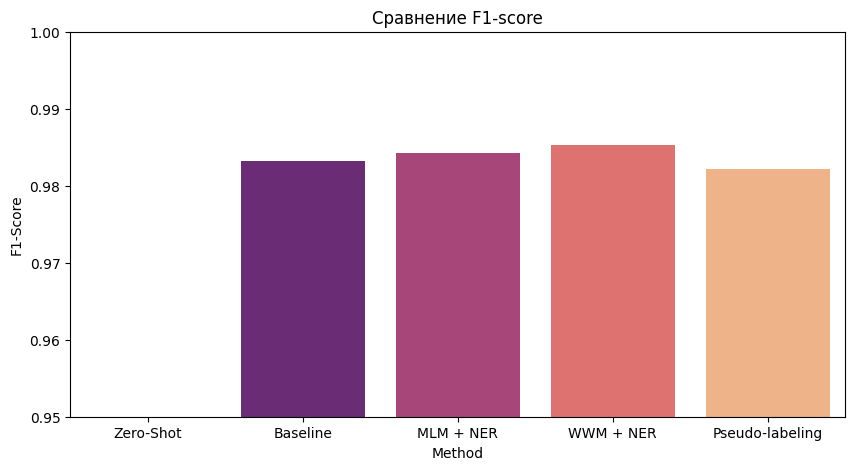

In [29]:
df_results = pd.DataFrame(list(results_summary.items()), columns=["Method", "F1-Score"])
print(df_results)

plt.figure(figsize=(10, 5))

sns.barplot(
    x="Method",
    y="F1-Score",
    data=df_results,
    hue="Method",
    palette="magma",
    legend=False
)

plt.ylim(0.95, 1.0)

plt.title("Сравнение F1-score")
plt.show()

Лучший результат получился при маскирование всего слова (то есть WWM). Я не знаю, это ожидаемый результат? Как будто бы да. Но хочется отметить что ячейка с WWM обучалась дольше всего (23 минуты).

Топ 2 у нас MLM, классика. Быстро и лучше бейзлайна

Топ 3, Baseline. Ну Baseline и Baseline

Топ 4, разметка через учителя. Хоть здесь это не дало сильного буста, но нельзя не отметить, что если у нас мало размеченных данных, а ручную разметку, либо разметку через LLM, делать дорого и долго, то вариант с быстрой черновой разметкой с хорошим учителем поможет повысить качество и позволит модели увидеть больше данных (пусть и местами шумными)